# 04 – Community Analysis

**Global Cargo Shipping Network (GCSN) — 2015 vs 2025**

Methodology follows **Kaluza et al. (2010)**, *J. R. Soc. Interface*, Figure 3.

The paper identifies geographically coherent trading communities using modularity-based detection.
Container ships: c=12, Q=0.605; Bulk dry: c=7, Q=0.592; Oil tankers: c=6, Q=0.716.

### Analyses performed
1. Louvain community detection (weighted undirected graph)
2. Modularity Q
3. Community size distribution
4. Community internal density
5. Community traffic (strength per community)
6. Top ports per community
7. Summary comparison table
8. **Inter-community traffic flow matrix**
9. **Per-community structural profile**
10. **Community persistence & evolution (2015 → 2025)**
11. **Community flow balance — net import/export (directed)**
12. **Community quality metrics — conductance & coverage**
13. **Full community summary & consolidated output**


In [ ]:
# Importing necessary libraries
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

from networkx.algorithms.community import greedy_modularity_communities, modularity

try:
    from networkx.algorithms.community import louvain_communities
    HAS_LOUVAIN = True
    print('Louvain available (NetworkX >= 2.7)')
except ImportError:
    HAS_LOUVAIN = False
    print('Louvain not available, using greedy modularity')

# Setting the plotting style and params for better plots and visualizations
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    plt.style.use('ggplot')

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 100,
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
})

# Defining the path where all plots and figures need to saved 
FIG_DIR = '../Figures/'
os.makedirs(FIG_DIR, exist_ok=True) # Creating the above dir if it doesn't exist already

# Printing to check if all imports are correct and working
print('NetworkX version:', nx.__version__)

Louvain available (NetworkX >= 2.7)
NetworkX version: 3.4.2


In [ ]:
# Loading the edge list data from the respective csv file paths into dataframes for both years
df_2015 = pd.read_csv('../EdgeList/shipping_network_2015.csv')
df_2025 = pd.read_csv('../EdgeList/shipping_network_2025.csv')

# Defining a helper function to build the weighted undirected graph from the given dataframe
def build_weighted_undirected(df):
    Gu = nx.Graph()
    for _, row in df.iterrows():
        u, v, w = row['source'], row['target'], row['weight']
        if Gu.has_edge(u, v):
            Gu[u][v]['weight'] += w
        else:
            Gu.add_edge(u, v, weight=w)
    return Gu

# Defining a helper function to build the weighted directed graph from the given dataframe
def build_directed_weighted(df):
    return nx.from_pandas_edgelist(
        df, 'source', 'target', edge_attr='weight',
        create_using=nx.DiGraph())

# Building the weighted undirected and directed graphs for both years
Gu_2015 = build_weighted_undirected(df_2015)
Gd_2015 = build_directed_weighted(df_2015)
Gu_2025 = build_weighted_undirected(df_2025)
Gd_2025 = build_directed_weighted(df_2025)

# Printing the basic stats of the above created graphs
print(f'2015: {Gu_2015.number_of_nodes():,} nodes, {Gu_2015.number_of_edges():,} edges')
print(f'2025: {Gu_2025.number_of_nodes():,} nodes, {Gu_2025.number_of_edges():,} edges')

2015: 7,097 nodes, 145,745 edges
2025: 7,717 nodes, 139,499 edges


## 1. Community Detection

We use **Louvain** (preferred, NetworkX >= 2.7) or **greedy modularity** as fallback.  
Both optimise the modularity Q = fraction of intra-community edges minus expectation under null model.


In [ ]:
# Defining a function to detect communities from the given undirected graph
def detect_communities(Gu, seed=42):
    """Detect communities on the weighted undirected graph `Gu`.

    Preferred method is Louvain (NetworkX >= 2.7). If unavailable or it fails,
    fall back to greedy modularity. Returns tuple: (communities, modularity Q, method).

    Each community is returned as a frozenset (or set-like) collection of node IDs.
    """
    # Trying the preferred Louvain implementation when available
    if HAS_LOUVAIN:
        try:
            comms = louvain_communities(Gu, weight='weight', seed=seed)
            method = 'Louvain'
        except Exception as e:
            # Fall back to greedy modularity if Louvain fails for any reason
            print(f'Louvain failed ({e}), falling back to greedy')
            comms = list(greedy_modularity_communities(Gu, weight='weight'))
            method = 'Greedy modularity'
    else:
        # If the NetworkX installation lacks Louvain API, we use the greedy modularity
        comms = list(greedy_modularity_communities(Gu, weight='weight'))
        method = 'Greedy modularity'

    # Computing the modularity Q for the partition
    Q = modularity(Gu, comms, weight='weight')

    # Printing a short summary for the communities and their corresponding modularity score as calculated above
    print(f'  Method: {method}')
    print(f'  Communities: {len(comms)}')
    print(f'  Modularity Q: {Q:.4f}')

    return comms, Q, method # Returning the communities, modularity score and the method used

# Running the detection and labelling outputs for both years
print('=== 2015 ===')
comms_2015, Q_2015, method_2015 = detect_communities(Gu_2015)

print('\n=== 2025 ===')
comms_2025, Q_2025, method_2025 = detect_communities(Gu_2025)


=== 2015 ===
  Method: Louvain
  Communities: 28
  Modularity Q: 0.6987

=== 2025 ===
  Method: Louvain
  Communities: 34
  Modularity Q: 0.7196


## 2. Community Metrics


In [ ]:
# Defining a function to compute key structural statistics for a given graph partition (set of communities) and prints a human-readable summary
def community_metrics(Gu, comms, label):
    node_to_comm = {}  # Maps each node (port) to the integer ID of its community
 
    # Iterating over each community and assign every member node its community index
    for i, c in enumerate(comms):
        for n in c:
            node_to_comm[n] = i
 
    sizes = np.array([len(c) for c in comms])  # Defining an array of community sizes (node counts)
 
    # Defining the counters for intra- vs inter-community edges and their total voyage weights
    intra, inter = 0, 0
    intra_w, inter_w = 0.0, 0.0
 
    # Walking along every edge in the undirected graph to classify it as internal or external
    for u, v, d in Gu.edges(data=True):
        w = d.get('weight', 1) # Edge weight (voyage count)
        if node_to_comm.get(u) == node_to_comm.get(v): # If both endpoints are in same community
            intra += 1 # Incrementing the intra-community edge count
            intra_w += w # Accumulating the intra-community voyage weight
        else: # If endpoints belong to different communities
            inter += 1 # Incrementing the inter-community edge count
            inter_w += w # Accumulating the inter-community voyage weight
 
    total_w = intra_w + inter_w # Calculating the total voyage weight across all edges
 
    # Computing the edge density for each community's induced subgraph
    # density = actual edges / maximum possible edges for n nodes
    densities = []
    for c in comms:
        sub = Gu.subgraph(c) # Creating a subgraph containing only nodes in community c
        n = sub.number_of_nodes()
        m = sub.number_of_edges()
        if n > 1: # Skipping singleton communities (density undefined)
            densities.append(2 * m / (n * (n - 1))) # Calculating the density for this community
 
    # Computing the total weighted degree (strength) for each community
    # This represents total voyage volume associated with each community
    comm_strengths = []
    for c in comms:
        sub = Gu.subgraph(c) # Creating a subgraph for community c

        # Summing the weighted degrees of all nodes -> captures total traffic volume
        comm_strengths.append(sum(dict(sub.degree(weight='weight')).values()))
 
    # Printing the formatted summary statistics for quick inspection
    print(f'\n=== Community Metrics: {label} ===')
    print(f'  Number of communities    : {len(comms)}')
    print(f'  Largest community (nodes): {sizes.max()}')
    print(f'  Smallest community       : {sizes.min()}')
    print(f'  Mean community size      : {sizes.mean():.1f}')
    print(f'  Intra-community edges    : {intra:,} ({intra/(intra+inter)*100:.1f}%)')
    print(f'  Inter-community edges    : {inter:,} ({inter/(intra+inter)*100:.1f}%)')
    print(f'  Intra-community traffic  : {intra_w/total_w*100:.1f}% of all voyages')
    print(f'  Mean internal density    : {np.mean(densities):.4f}')
 
    # Returning a dict of arrays/scalars for use in downstream cells
    return {
        'sizes': sizes,
        'densities': densities,
        'comm_strengths': np.array(comm_strengths),
        'intra_edges': intra, 'inter_edges': inter,
        'intra_ratio': intra / (intra + inter), # Fraction of edges that are internal
        'intra_traffic_ratio': intra_w / total_w, # Fraction of voyages that are internal
        'node_to_comm': node_to_comm, # Node → community lookup, reused later
    }
 
 
# Computing the community_metrics for both years
cm_2015 = community_metrics(Gu_2015, comms_2015, '2015')
cm_2025 = community_metrics(Gu_2025, comms_2025, '2025')


=== Community Metrics: 2015 ===
  Number of communities    : 28
  Largest community (nodes): 1990
  Smallest community       : 2
  Mean community size      : 253.5
  Intra-community edges    : 102,314 (70.2%)
  Inter-community edges    : 43,431 (29.8%)
  Intra-community traffic  : 84.2% of all voyages
  Mean internal density    : 0.4647

=== Community Metrics: 2025 ===
  Number of communities    : 34
  Largest community (nodes): 1735
  Smallest community       : 2
  Mean community size      : 227.0
  Intra-community edges    : 94,301 (67.6%)
  Inter-community edges    : 45,198 (32.4%)
  Intra-community traffic  : 83.4% of all voyages
  Mean internal density    : 0.3605


## 3. Community Size Distribution


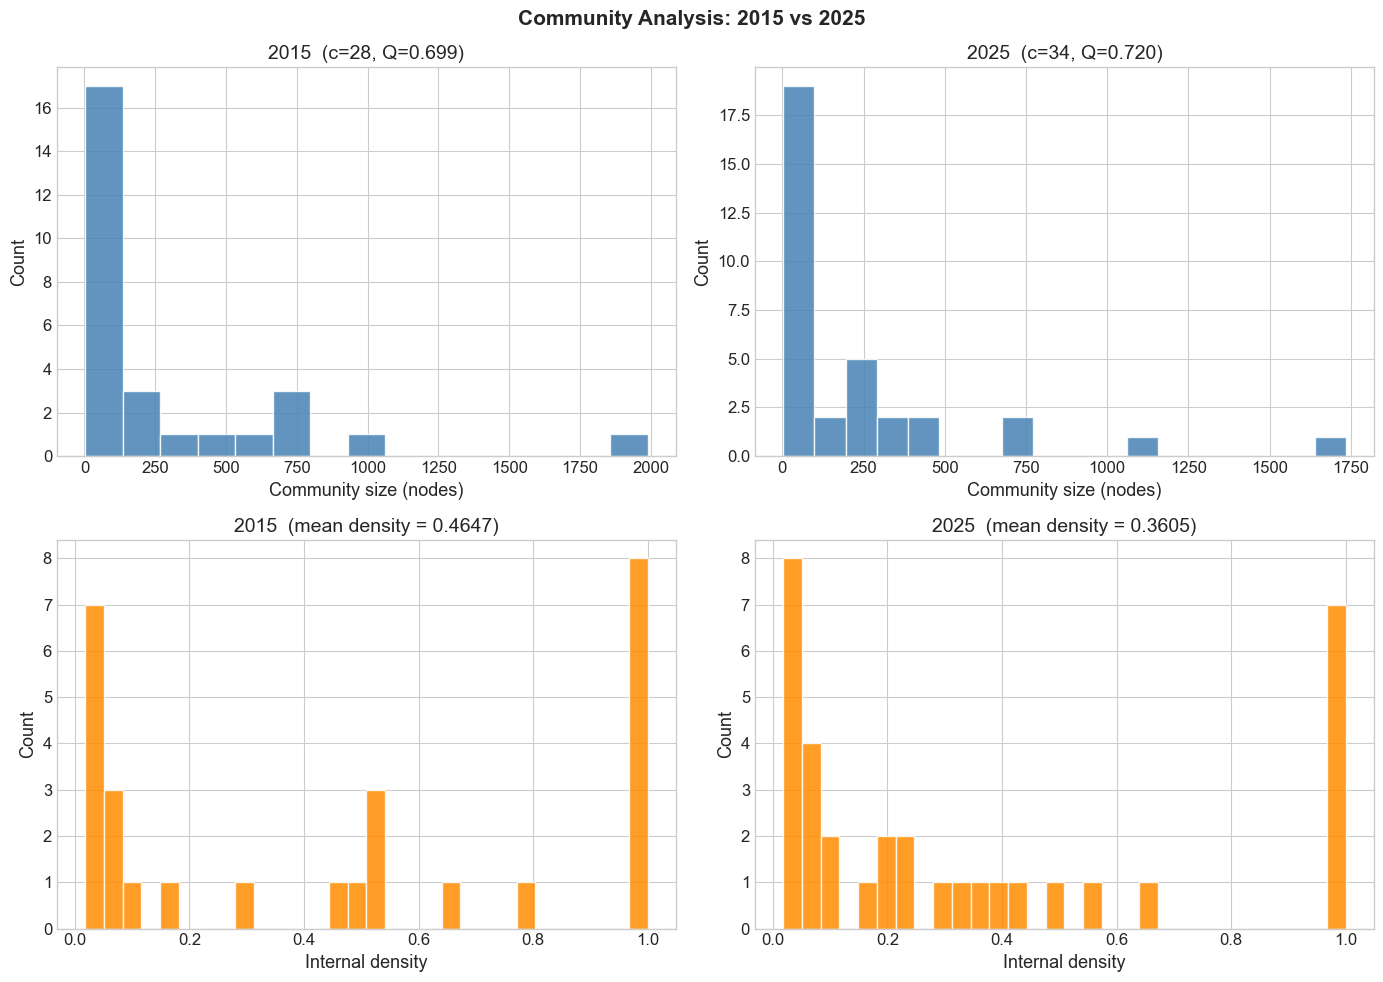

In [ ]:
# Defining a 2-row × 2-column grid where top row is for size histograms, and bottom row is for density histograms
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Community Analysis: 2015 vs 2025', fontsize=15, fontweight='bold')
 
# Loopping over both years and their corresponding community metrics
for col, (year, cm, Q) in enumerate([
    ('2015', cm_2015, Q_2015),
    ('2025', cm_2025, Q_2025)
]):
    # Extracting the community sizes and densities for this year
    sizes = cm['sizes']
    densities = np.array(cm['densities'])
 
    # Plotting the Top row which is the community size distribution
    ax = axes[0, col]
    ax.hist(sizes, bins=min(40, len(sizes)//2+1), edgecolor='white',
            color='steelblue', alpha=0.85) # Capping the bins to avoid over-fragmentation
    ax.set_xlabel('Community size (nodes)')
    ax.set_ylabel('Count')
    ax.set_title(f'{year}  (c={len(sizes)}, Q={Q:.3f})') # Showing community count & modularity
 
    # Plotting the bottom row which is the internal density distribution
    ax2 = axes[1, col]
    ax2.hist(densities, bins=30, edgecolor='white',
             color='darkorange', alpha=0.85)
    ax2.set_xlabel('Internal density')
    ax2.set_ylabel('Count')
    ax2.set_title(f'{year}  (mean density = {np.mean(densities):.4f})')
 
plt.tight_layout()
plt.savefig(FIG_DIR + '04_community_size.png', dpi=150, bbox_inches='tight')  # Save figure
plt.show()

## 4. Community Strength (Traffic) Distribution


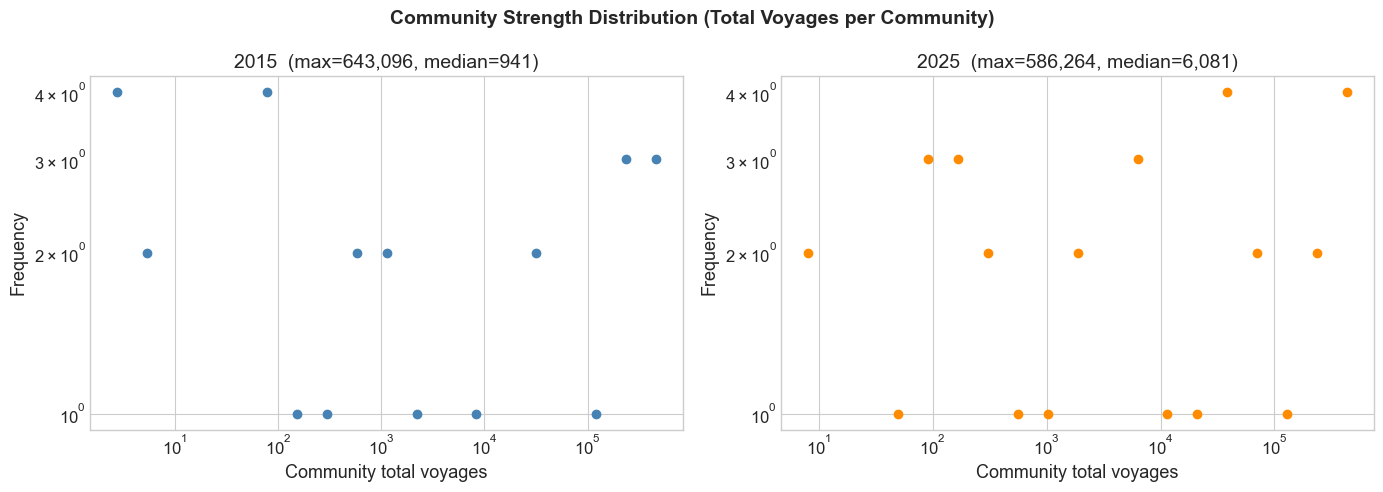

In [ ]:
# Plotting the side-by-side log-log plots which reveal whether community strength follows a power law
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Community Strength Distribution (Total Voyages per Community)',
             fontsize=14, fontweight='bold')

# Iterating over the years and their corresponding community metrics
for ax, (year, cm, color) in zip(axes, [
    ('2015', cm_2015, 'steelblue'),
    ('2025', cm_2025, 'darkorange')
]):
    
    # Extracting the community strengths for the graph of this year
    cs = cm['comm_strengths']
    cs_nz = cs[cs > 0] # Excluding empty/zero-strength communities
 
    if len(cs_nz) > 1:
        # Creating logarithmically-spaced bin edges to handle wide range of strengths
        bins = np.logspace(np.log10(cs_nz.min()), np.log10(cs_nz.max()), 20)
        h, edges = np.histogram(cs_nz, bins=bins)
        centres = np.sqrt(edges[:-1] * edges[1:]) # Using the geometric mean as representative bin centre
        ax.loglog(centres[h > 0], h[h > 0], 'o', ms=6, color=color) # Log-log scatter plot; skipping empty bins
 
    ax.set_xlabel('Community total voyages')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{year}  (max={int(cs.max()):,}, median={int(np.median(cs)):,})')

# Fixing the layout, saving the plot to the specified file name, and showing the plot
plt.tight_layout()
plt.savefig(FIG_DIR + '04_community_strength.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Top Ports per Community (Largest Communities)


In [ ]:
# Prints the highest-strength ports inside each of the N largest communities, giving an intuitive geographic label to otherwise abstract cluster IDs
def top_ports_per_community(Gu, comms, year, n_comms=8, ports_per_comm=8):

    """Print top ports by strength for the largest communities."""

    # Sorting the given communities by descending size so the most prominent appear first
    sorted_comms = sorted(enumerate(comms), key=lambda x: len(x[1]), reverse=True)
 
    print(f'\n=== Top ports per community — {year} (top {n_comms} communities by size) ===')
 
    for rank, (i, c) in enumerate(sorted_comms[:n_comms]): # Iterating over the top-n communities

        sub = Gu.subgraph(c) # Creating a subgraph for this community

        # Ranking ports by weighted degree (total voyage volume) and take the top few
        top = sorted(sub.degree(weight='weight'), key=lambda x: x[1], reverse=True)[:ports_per_comm]
        port_str = ', '.join(f'{p}({w:,})' for p, w in top)  # Formatting as "PORT(count)" pairs
        print(f'  Comm {rank+1:>2} (size={len(c):>4}): {port_str}')
 
 
# Running the above defined function for both years
top_ports_per_community(Gu_2015, comms_2015, '2015')
top_ports_per_community(Gu_2025, comms_2025, '2025')


=== Top ports per community — 2015 (top 8 communities by size) ===
  Comm  1 (size=1990): nld-rotterdammaasvlakte(22,291), bel-antwerp(17,928), deu-brunsbuttel(16,366), deu-strande(14,007), gbr-erith(11,267), deu-bremerhaven(11,130), deu-cuxhaven(10,474), deu-deu-482(9,755)
  Comm  2 (size= 970): tur-istanbul(28,151), rus-kavkaz(18,013), grc-piraeus(9,950), tur-yalovatown(8,458), egy-portsaid(8,356), rus-azov(7,410), esp-valencia(7,401), tur-ambarli(7,188)
  Comm  3 (size= 765): pan-manzanillo(9,738), pan-gatunlakeanchorage(6,909), pan-panamaanchoragepacific(5,861), usa-houston(5,018), col-cartagena(4,652), pan-panamacanalanchorage(4,651), usa-newyork(4,228), per-callao(4,081)
  Comm  4 (size= 715): mys-pengerang(16,726), mys-portklang(16,653), are-jebelali(12,804), sgp-singapore(12,276), idn-jakarta(10,201), lka-colombo(7,102), mys-tanjungpelepas(6,845), idn-surabaya(6,752)
  Comm  5 (size= 689): chn-shanghai(101,236), chn-ningbo(52,223), chn-caofeidian(24,488), chn-dalian(21,688), c

## 6. Summary Comparison Table


In [ ]:
# Building the list of row tuples for the summary table
rows = [
    ('Metric',                          '2015',                              '2025',                              'Paper 2007'),
    ('Detection method',                 method_2015,                         method_2025,                         'Louvain'),
    ('Number of communities c',          str(len(comms_2015)),                str(len(comms_2025)),                '12 (container) / 7 (bulk) / 6 (oil)'),
    ('Modularity Q',                     f'{Q_2015:.4f}',                     f'{Q_2025:.4f}',                     '0.605 / 0.592 / 0.716'),
    ('Largest community (nodes)',        f'{cm_2015["sizes"].max()}',         f'{cm_2025["sizes"].max()}',         '—'),
    ('Smallest community (nodes)',       f'{cm_2015["sizes"].min()}',         f'{cm_2025["sizes"].min()}',         '—'),
    ('Mean community size',              f'{cm_2015["sizes"].mean():.1f}',    f'{cm_2025["sizes"].mean():.1f}',    '—'),
    ('Intra-community edge ratio',       f'{cm_2015["intra_ratio"]*100:.1f}%', f'{cm_2025["intra_ratio"]*100:.1f}%', '—'),
    ('Intra-community traffic ratio',    f'{cm_2015["intra_traffic_ratio"]*100:.1f}%',
                                         f'{cm_2025["intra_traffic_ratio"]*100:.1f}%', '—'),
    ('Mean internal density',            f'{np.mean(cm_2015["densities"]):.4f}',
                                         f'{np.mean(cm_2025["densities"]):.4f}', '—'),
]
 
# Converting the above created row list to DataFrame, using first row as column headers
df_sum = pd.DataFrame(rows[1:], columns=rows[0])
 
# Pretty-printing the table with separator lines for readability
print()
print('=' * 90)
print('  GCSN COMMUNITY ANALYSIS — SUMMARY TABLE')
print('  Reference: Kaluza et al. (2010), J. R. Soc. Interface')
print('=' * 90)
print(df_sum.to_string(index=False))
print('=' * 90)
 
# Persisting the table to CSV for later use
df_sum.to_csv('../Figures/04_community_summary.csv', index=False)
print('\nSaved to ../Figures/04_community_summary.csv')


  GCSN COMMUNITY ANALYSIS — SUMMARY TABLE
  Reference: Kaluza et al. (2010), J. R. Soc. Interface
                       Metric    2015    2025                          Paper 2007
             Detection method Louvain Louvain                             Louvain
      Number of communities c      28      34 12 (container) / 7 (bulk) / 6 (oil)
                 Modularity Q  0.6987  0.7196               0.605 / 0.592 / 0.716
    Largest community (nodes)    1990    1735                                   —
   Smallest community (nodes)       2       2                                   —
          Mean community size   253.5   227.0                                   —
   Intra-community edge ratio   70.2%   67.6%                                   —
Intra-community traffic ratio   84.2%   83.4%                                   —
        Mean internal density  0.4647  0.3605                                   —

Saved to ../Figures/04_community_summary.csv


---
## 7. Inter-Community Traffic Flow Matrix

A **C × C** matrix where entry (i, j) = total directed voyages from community i to community j.

The diagonal = internal traffic.  Off-diagonal = cross-community trade flows.

We visualise the top-N communities by size as a heatmap to identify which clusters are tightly coupled and which are isolated.

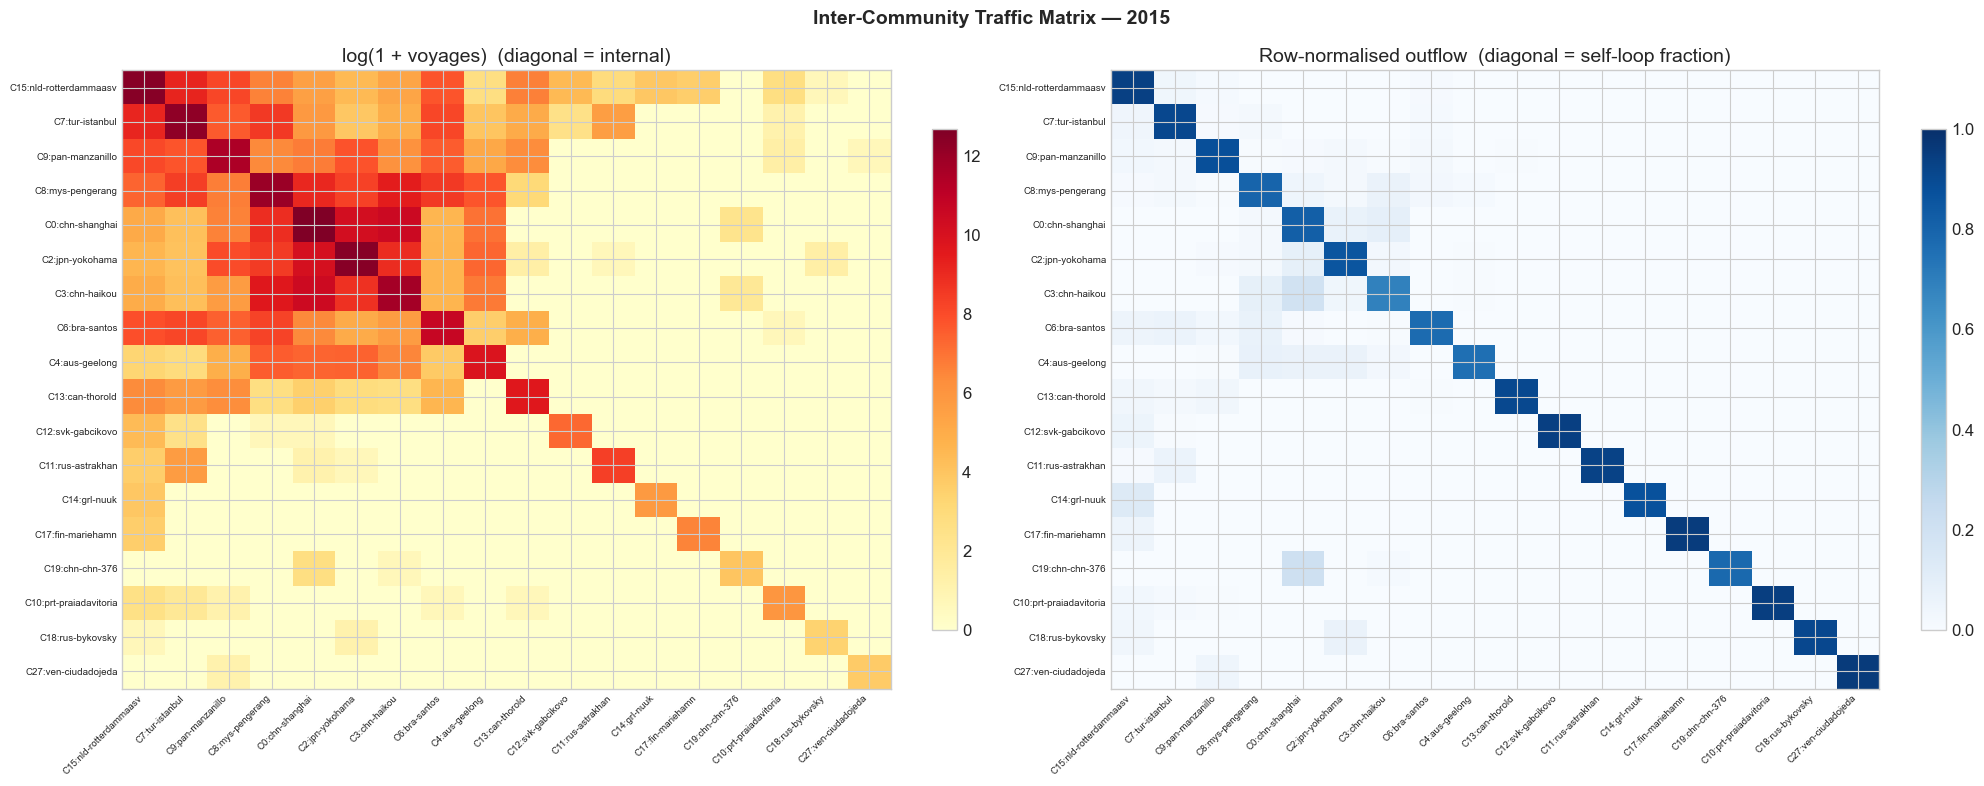

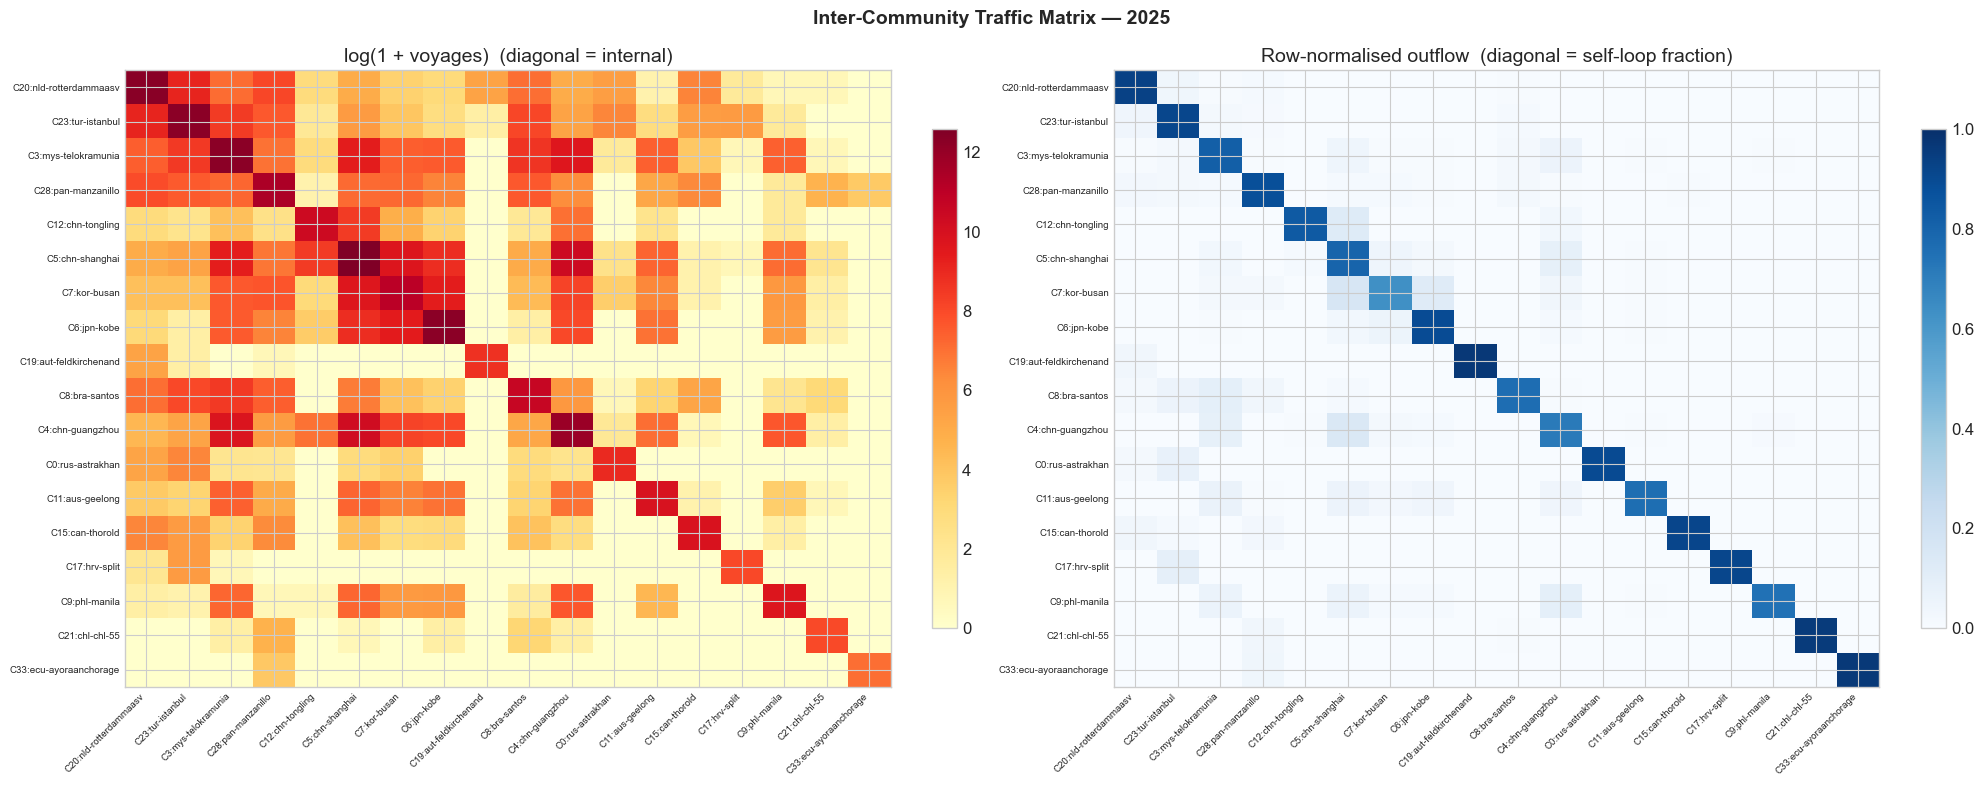


Top 15 inter-community flows — 2015
    From community       To community  Voyages  From size  To size
      chn-shanghai         chn-haikou    35261        689      406
        chn-haikou       chn-shanghai    34271        406      689
      chn-shanghai       jpn-yokohama    26631        689      615
      jpn-yokohama       chn-shanghai    24413        615      689
        chn-haikou      mys-pengerang    15010        406      715
     mys-pengerang         chn-haikou    12598        715      406
nld-rotterdammaasv       tur-istanbul    10012       1990      970
      tur-istanbul nld-rotterdammaasv     9460        970     1990
     mys-pengerang       chn-shanghai     8660        715      689
      jpn-yokohama         chn-haikou     7735        615      406
      chn-shanghai      mys-pengerang     7304        689      715
        chn-haikou       jpn-yokohama     6491        406      615
      tur-istanbul      mys-pengerang     5218        970      715
     mys-pengerang       

In [ ]:
# Importing the necessary libraries for this analysis
from collections import defaultdict

TOP_HEATMAP = 18   # Defining the threshold to show the no. of top communities by size in the heatmap

# Defining a helper function to build the inter community matrix given the graph and communities
def build_inter_community_matrix(Gd_w, comms, node_to_comm):

    """Build directed C×C traffic matrix in one O(E) pass."""

    n_comms = len(comms) # Storing the number of communities in the given graph
    traffic = defaultdict(float) # Dictionary to store the weights for community matrix

    # Iterating over the edges of the given directed weighted graph
    for u, v, d in Gd_w.edges(data=True):

        # Getting the community ids for the two endpoints of the current edge
        cu = node_to_comm.get(u) 
        cv = node_to_comm.get(v)
        if cu is not None and cv is not None: # Adding the weight to  the above defined dict
            traffic[(cu, cv)] += d.get('weight', 1)

    # Converting to dense matrix
    mat = np.zeros((n_comms, n_comms))
    for (i, j), w in traffic.items():
        mat[i, j] = w
    return mat

# Defining a function to get the port label for the given community based on highest strength
def top_port_label(comm_nodes, Gu, max_label=18):

    """Return the highest-strength port as a community label."""

    sub = Gu.subgraph(comm_nodes) # Creating a subgraph for this given community
    if sub.number_of_nodes() == 0: # If the graph is empty
        return '(empty)'
    top = max(sub.degree(weight='weight'), key=lambda x: x[1])[0] # Sorting the ports in the community by strength
    return top[:max_label] # Getting the required number of labels from the community based on highest strengths

# Defining a function to plot the community interaction heatmap
def plot_community_heatmap(mat_full, comms, Gu, year, top_n=TOP_HEATMAP):

    """Heatmap of inter-community traffic for the top-n largest communities."""

    # Ranking by community size, and picking top-n communities
    sizes    = np.array([len(c) for c in comms])
    top_idx  = np.argsort(sizes)[::-1][:top_n]
    sub_mat  = mat_full[np.ix_(top_idx, top_idx)]

    # Normalising the rows so each row sums to 1 (shows outflow profile)
    row_sums = sub_mat.sum(axis=1, keepdims=True)
    row_sums = np.where(row_sums == 0, 1, row_sums)
    norm_mat = sub_mat / row_sums

    # Getting the port label for each of the top communities
    labels = [f'C{idx}:{top_port_label(comms[idx], Gu)}' for idx in top_idx]

    # Plotting the community interaction heatmap
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle(f'Inter-Community Traffic Matrix — {year}',
                 fontsize=14, fontweight='bold')

    # Plotting the raw counts (on a log scale)
    log_mat = np.log1p(sub_mat)
    im0 = axes[0].imshow(log_mat, aspect='auto', cmap='YlOrRd')
    axes[0].set_xticks(range(len(labels))); axes[0].set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
    axes[0].set_yticks(range(len(labels))); axes[0].set_yticklabels(labels, fontsize=7)
    axes[0].set_title('log(1 + voyages)  (diagonal = internal)')
    plt.colorbar(im0, ax=axes[0], fraction=0.03)

    # Plotting the row-normalised (outflow profile)
    im1 = axes[1].imshow(norm_mat, aspect='auto', cmap='Blues', vmin=0, vmax=1)
    axes[1].set_xticks(range(len(labels))); axes[1].set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
    axes[1].set_yticks(range(len(labels))); axes[1].set_yticklabels(labels, fontsize=7)
    axes[1].set_title('Row-normalised outflow  (diagonal = self-loop fraction)')
    plt.colorbar(im1, ax=axes[1], fraction=0.03)

    # Fixing teh layout, saving the plot in the specified filename and showing the plot
    plt.tight_layout()
    plt.savefig(FIG_DIR + f'04_community_heatmap_{year}.png', dpi=150, bbox_inches='tight')
    plt.show()
    return sub_mat, norm_mat, top_idx

# Building the community map for both years
mat_2015 = build_inter_community_matrix(Gd_2015, comms_2015, cm_2015['node_to_comm'])
mat_2025 = build_inter_community_matrix(Gd_2025, comms_2025, cm_2025['node_to_comm'])

# Plotting the heatmap for both years
sub_mat_15, norm_mat_15, top_idx_15 = plot_community_heatmap(mat_2015, comms_2015, Gu_2015, '2015')
sub_mat_25, norm_mat_25, top_idx_25 = plot_community_heatmap(mat_2025, comms_2025, Gu_2025, '2025')

# Defining a function tp print the top inter-community flows (off-diagonal)
def top_inter_flows(mat_full, comms, Gu, year, top_n=15):
    n = len(comms)
    flows = []
    for i in range(n):
        for j in range(n):
            if i != j and mat_full[i, j] > 0:
                label_i = top_port_label(comms[i], Gu)
                label_j = top_port_label(comms[j], Gu)
                flows.append((label_i, label_j, int(mat_full[i, j]),
                              len(comms[i]), len(comms[j])))
    flows.sort(key=lambda x: x[2], reverse=True)
    df_flows = pd.DataFrame(flows[:top_n],
                             columns=['From community', 'To community',
                                      'Voyages', 'From size', 'To size'])
    print(f'\nTop {top_n} inter-community flows — {year}')
    print(df_flows.to_string(index=False))
    return df_flows

# Printing the selected few top flows between communities for both years
top_flows_15 = top_inter_flows(mat_2015, comms_2015, Gu_2015, '2015')
top_flows_25 = top_inter_flows(mat_2025, comms_2025, Gu_2025, '2025')


---
## 8. Per-Community Structural Profile

For each community we compute a set of structural metrics that describe its internal organisation:

| Metric | Description |
|--------|-------------|
| Size | number of port nodes |
| Internal edges | edges with both endpoints inside the community |
| Int. density | 2·E_int / (n·(n-1)) — how complete the community subgraph is |
| Mean degree | average undirected degree within the community subgraph |
| Clustering C | average clustering coefficient inside the community |
| Total strength | sum of all internal + external edge weights for community nodes |
| Internal traffic | fraction of node strength that stays inside the community |
| Top port | highest-strength port (community "hub") |


Per-community structural profile — 2015  (22 communities with size >= 3)
 Comm ID  Size (nodes)  Int. edges  Int. density  Mean degree  Clustering C  Total strength  Int. traffic %     Top port (hub)
      15          1990       35364       0.01787        35.54        0.4919          553326            46.7 nld-rotterdammaasv
       7           970       17507       0.03725        36.10        0.5183          466467            45.5       tur-istanbul
       9           765        7375       0.02524        19.28        0.5177          213625            44.0     pan-manzanillo
       8           715        9226       0.03614        25.81        0.5942          392431            40.0      mys-pengerang
       0           689       10539       0.04447        30.59        0.6745          785511            40.9       chn-shanghai
       2           615       12361       0.06547        40.20        0.6254          592551            43.0       jpn-yokohama
       3           406        3951   

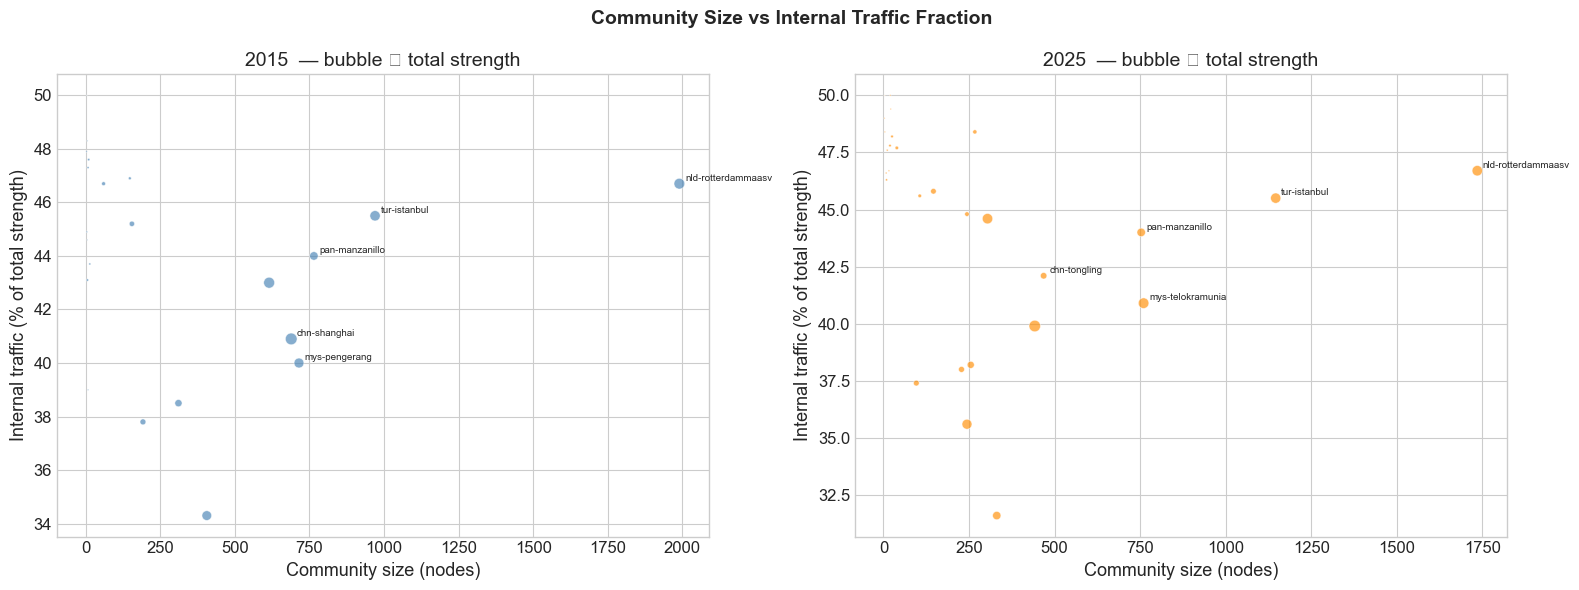

In [ ]:
# Defining a function to build a rich DataFrame of per-community statistics and produce a scatter plot of community size vs internal traffic fraction (bubble size ∝ total strength)
def per_community_profile(Gu, Gd_w, comms, mat_full, label, min_size=3):

    """Build a per-community profile DataFrame."""

    rows = []
    for i, comm in enumerate(comms): # Iterating over all communities
        if len(comm) < min_size:       # Skipping the tiny communities that are likely noise
            continue
        sub   = Gu.subgraph(comm)      # Ceating an undirected subgraph for this community
        n     = sub.number_of_nodes()
        m     = sub.number_of_edges()
        int_density = 2 * m / (n * (n-1)) if n > 1 else 0   # Calculating the internal edge density for this community
        mean_k      = np.mean([d for _, d in sub.degree()]) if n > 0 else 0  # Calculating the mean unweighted degree
        C           = nx.average_clustering(sub) if n > 2 else 0  # Calculating the avg clustering coefficient (needs ≥3 nodes)
 
        # Calculating the total voyage strength of all ports in this community (using the full graph, not just the subgraph, to include inter-community edges)
        total_s = sum(Gu.degree(p, weight='weight') for p in comm)
 
        # Diagonal entry of the traffic matrix = voyages that start AND end within the community
        int_traffic = mat_full[i, i]
        int_ratio   = int_traffic / total_s if total_s > 0 else 0  # Calculating the fraction of traffic that is internal
 
        # Representative label: the port with highest weighted degree in the subgraph
        top_p = top_port_label(comm, Gu)
 
        # Appending the above calculated results to the abode defined list
        rows.append({
            'Comm ID': i,
            'Size (nodes)': n,
            'Int. edges': m,
            'Int. density': round(int_density, 5),
            'Mean degree': round(mean_k, 2),
            'Clustering C': round(C, 4),
            'Total strength': int(total_s),
            'Int. traffic %': round(int_ratio * 100, 1),
            'Top port (hub)': top_p,
        })
 
    # Sorting the rows by size descending so largest communities appear first and printing the dataframe
    df = pd.DataFrame(rows).sort_values('Size (nodes)', ascending=False)
    print(f'\nPer-community structural profile — {label}  ({len(df)} communities with size >= {min_size})')
    print(df.to_string(index=False))

    # Saving the dataframe as a csv file
    df.to_csv(FIG_DIR + f'04_community_profile_{label}.csv', index=False)
    print(f'Saved → ../Figures/04_community_profile_{label}.csv')
    return df
 
# Computing the community profiles for both years
prof_2015 = per_community_profile(Gu_2015, Gd_2015, comms_2015, mat_2015, '2015')
prof_2025 = per_community_profile(Gu_2025, Gd_2025, comms_2025, mat_2025, '2025')
 
# Plotting the scatter plot of size vs internal traffic % and bubble size ∝ total strength
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Community Size vs Internal Traffic Fraction',
             fontsize=14, fontweight='bold')

# Iterating over each year and its corresponding community profile
for ax, (prof, year, color) in zip(axes, [
    (prof_2015, '2015', 'steelblue'),
    (prof_2025, '2025', 'darkorange'),
]):

    # Plotting the scatter plot of size vs internal traffic %
    sc = ax.scatter(prof['Size (nodes)'], prof['Int. traffic %'],
                    s=np.sqrt(prof['Total strength'].clip(1)) * 0.08,  # Bubble area scales with voyage volume
                    alpha=0.65, color=color, edgecolors='white', linewidth=0.5)
 
    # Annotating the 5 largest communities with their hub port name
    for _, row in prof.head(5).iterrows():
        ax.annotate(row['Top port (hub)'], (row['Size (nodes)'], row['Int. traffic %']),
                    fontsize=7, xytext=(4, 2), textcoords='offset points')
 
    ax.set_xlabel('Community size (nodes)')
    ax.set_ylabel('Internal traffic (% of total strength)')
    ax.set_title(f'{year}  — bubble ∝ total strength')
 
# Fixing the layout, saving the plot generated to the given filename and showing the plot
plt.tight_layout()
plt.savefig(FIG_DIR + '04_community_profile_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Community Persistence & Evolution — 2015 → 2025

How stable are the communities over the decade?

We match each **2015 community** to its best **2025 counterpart** using **Jaccard similarity** on shared port memberships:

$$J(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

- **J ≈ 1**: the community is essentially unchanged
- **J ≈ 0**: the community dissolved and ports redistributed

We also identify **newly formed** 2025 communities (no strong 2015 match) and **dissolved** 2015 communities (no strong 2025 match).

Community matching: 2015 → 2025  (Jaccard threshold = 0.25)
 2015 comm           2015 hub  2015 size  → 2025 comm           2025 hub  2025 size  Jaccard          Status
        25  aus-portmacquarie          2           31  aus-portmacquarie          2   1.0000          stable
        13        can-thorold        155           15        can-thorold        146   0.7602          stable
        10 prt-praiadavitoria          8            1 prt-praiadavitoria          9   0.7000          stable
        14           grl-nuuk         14           22           grl-nuuk         19   0.6500          stable
        15 nld-rotterdammaasv       1990           20 nld-rotterdammaasv       1735   0.6015          stable
         8      mys-pengerang        715            3   mys-telokramunia        760   0.5980          stable
         7       tur-istanbul        970           23       tur-istanbul       1146   0.5559          stable
         6         bra-santos        311            8         bra-sa

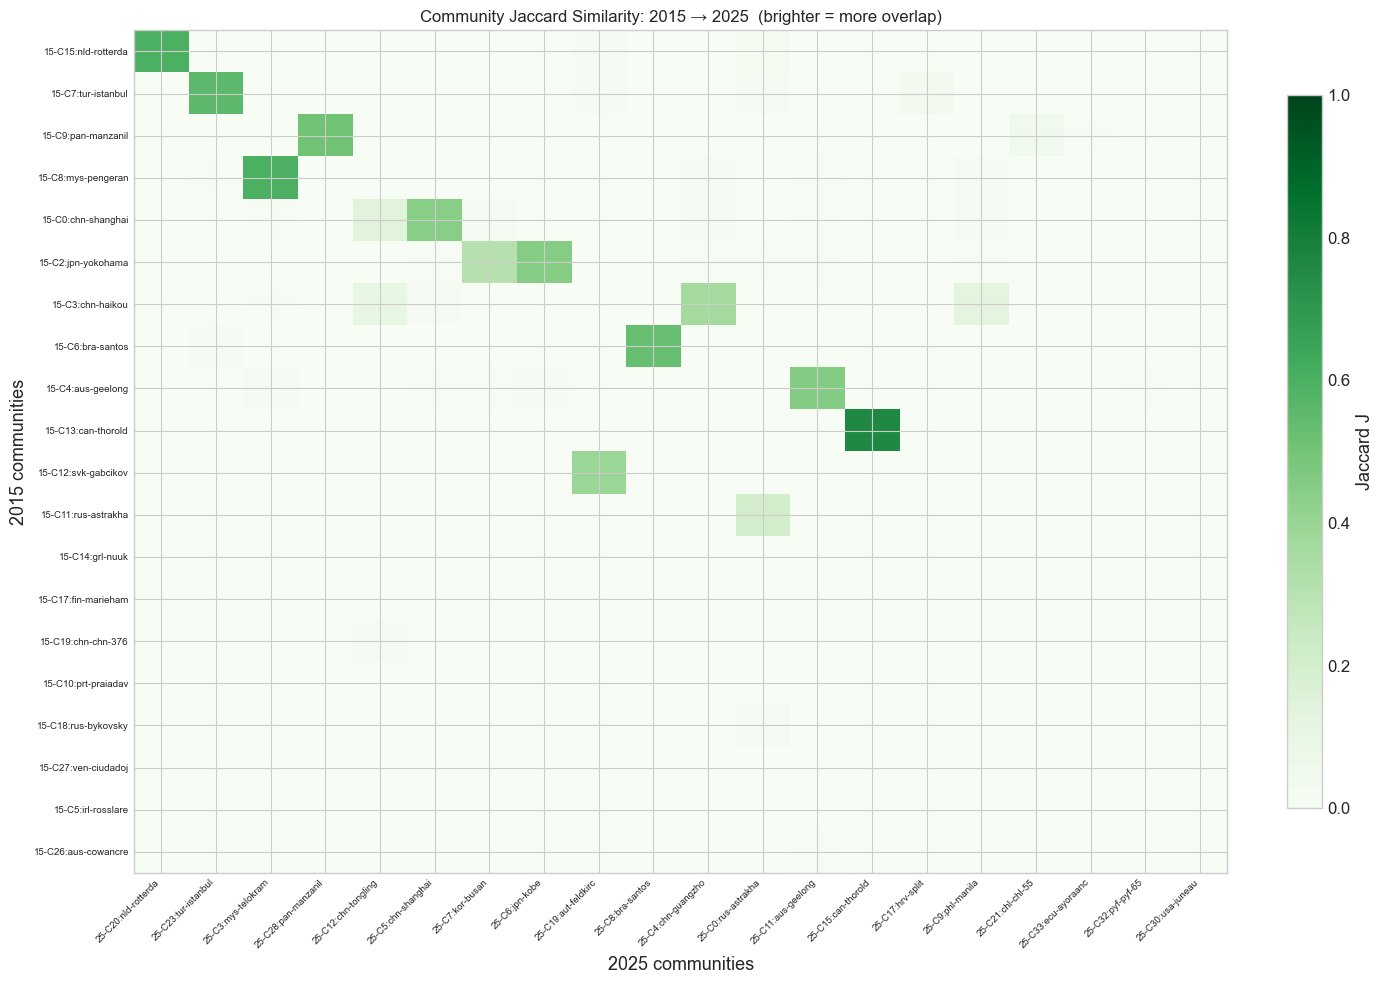


Matching table saved → ../Figures/04_community_matching.csv


In [ ]:
JACCARD_THRESH = 0.25 # Setting the minimum Jaccard similarity to consider two communities "the same"
 
# Defining a function that computes the full Jaccard similarity matrix between every 2015 and 2025 community pair
def community_jaccard_matrix(comms_a, comms_b):

    """Compute Jaccard similarity for every pair (a_i, b_j)."""

    # Converting the community node lists to sets for O(1) intersection
    sets_a = [set(c) for c in comms_a] 
    sets_b = [set(c) for c in comms_b]

    # Initialising |comms_a| × |comms_b| similarity matrix
    J = np.zeros((len(sets_a), len(sets_b)))  
    for i, a in enumerate(sets_a):
        for j, b in enumerate(sets_b):
            inter = len(a & b) # Number of shared nodes
            if inter > 0: # Skipping pairs with no overlap (leave as 0)
                J[i, j] = inter / len(a | b) # Calculating the Jaccard Similarity = |intersection| / |union|
    return J
 
 
# Building the full cross-year Jaccard similarity matrix for both years
J_mat = community_jaccard_matrix(comms_2015, comms_2025)
 
# For each 2015 community, finding the 2025 community with the highest Jaccard score
match_rows = []
for i in range(len(comms_2015)):
    best_j   = int(np.argmax(J_mat[i]))  # Index of best-matching 2025 community
    best_jac = J_mat[i, best_j]          # Jaccard score of that best match
    hub_15   = top_port_label(comms_2015[i], Gu_2015)   # Representative hub port in 2015
    hub_25   = top_port_label(comms_2025[best_j], Gu_2025)  # Representative hub port in 2025

    # Labelling as "stable" if Jaccard meets threshold, otherwise "dissolved/split"
    status   = 'stable' if best_jac >= JACCARD_THRESH else 'dissolved/split'
    match_rows.append({
        '2015 comm': i,
        '2015 hub': hub_15,
        '2015 size': len(comms_2015[i]),
        '→ 2025 comm': best_j,
        '2025 hub': hub_25,
        '2025 size': len(comms_2025[best_j]),
        'Jaccard': round(best_jac, 4),
        'Status': status,
    })
 
# Sorting by Jaccard descending so most stable communities appear first
df_match = pd.DataFrame(match_rows).sort_values('Jaccard', ascending=False)
print('Community matching: 2015 → 2025  (Jaccard threshold = {:.2f})'.format(JACCARD_THRESH))
print(df_match.to_string(index=False))
 
# Counting the stable vs dissolved/split communities for summary reporting
n_stable    = (df_match['Status'] == 'stable').sum()
n_dissolved = (df_match['Status'] == 'dissolved/split').sum()
print(f'\n  Stable communities   : {n_stable}  (Jaccard >= {JACCARD_THRESH})')
print(f'  Dissolved/split      : {n_dissolved}')
 
# ── Jaccard heatmap (top 20 communities by size from each year) ──────────────
n_show_a = min(20, len(comms_2015))   # Cap display at 20 rows
n_show_b = min(20, len(comms_2025))   # Cap display at 20 columns
 
# Selecting the indices of the largest communities in each year for a focused view
top_a = np.argsort([len(c) for c in comms_2015])[::-1][:n_show_a]
top_b = np.argsort([len(c) for c in comms_2025])[::-1][:n_show_b]
J_sub = J_mat[np.ix_(top_a, top_b)]  # Slicing the full matrix to the top communities only
 
# Building the descriptive axis labels combining community index and hub port name
labels_a = [f'15-C{i}:{top_port_label(comms_2015[i], Gu_2015, 12)}' for i in top_a]
labels_b = [f'25-C{j}:{top_port_label(comms_2025[j], Gu_2025, 12)}' for j in top_b]

# Plotting the Jaccard heatmap
fig, ax = plt.subplots(figsize=(max(10, n_show_b*0.7), max(7, n_show_a*0.5)))
im = ax.imshow(J_sub, aspect='auto', cmap='Greens', vmin=0, vmax=1)  # Green intensity = Jaccard score
ax.set_xticks(range(n_show_b)); ax.set_xticklabels(labels_b, rotation=45, ha='right', fontsize=7)
ax.set_yticks(range(n_show_a)); ax.set_yticklabels(labels_a, fontsize=7)
ax.set_xlabel('2025 communities'); ax.set_ylabel('2015 communities')
ax.set_title('Community Jaccard Similarity: 2015 → 2025  (brighter = more overlap)',
             fontsize=12)
plt.colorbar(im, ax=ax, fraction=0.03, label='Jaccard J')
plt.tight_layout()
plt.savefig(FIG_DIR + '04_community_jaccard.png', dpi=150, bbox_inches='tight')
plt.show()
 
# Persisting the matching table
df_match.to_csv(FIG_DIR + '04_community_matching.csv', index=False)
print('\nMatching table saved → ../Figures/04_community_matching.csv')

---
## 10. Community Flow Balance — Net Import / Export (Directed)

Using the **directed** weighted graph, for each community we compute:

- **Inflow**: total voyages arriving at ports in this community from outside
- **Outflow**: total voyages departing from ports in this community to outside
- **Balance** = Inflow − Outflow
  - Positive balance → **net importer** (more ships arriving than departing)
  - Negative balance → **net exporter** (more ships leaving than arriving)

This mirrors the paper's observation that different port clusters have asymmetric trade roles.


Community flow balance — 2015
 Comm ID     Top port (hub)  Size  Inflow  Outflow  Balance  Balance %         Role
       6         bra-santos   311   13183    12978      205        0.8 net importer
      15 nld-rotterdammaasv  1990   18313    18161      152        0.4 net importer
       8      mys-pengerang   715   39473    39374       99        0.1 net importer
       3         chn-haikou   406   57377    57287       90        0.1 net importer
       4        aus-geelong   192    6123     6036       87        0.7 net importer
       9     pan-manzanillo   765   12762    12683       79        0.3 net importer
      13        can-thorold   155    1631     1581       50        1.6 net importer
       7       tur-istanbul   970   21063    21044       19        0.0 net importer
      18       rus-bykovsky     6       4        3        1       14.3 net importer
      14           grl-nuuk    14      47       47        0        0.0     balanced
      17      fin-mariehamn    10      36    

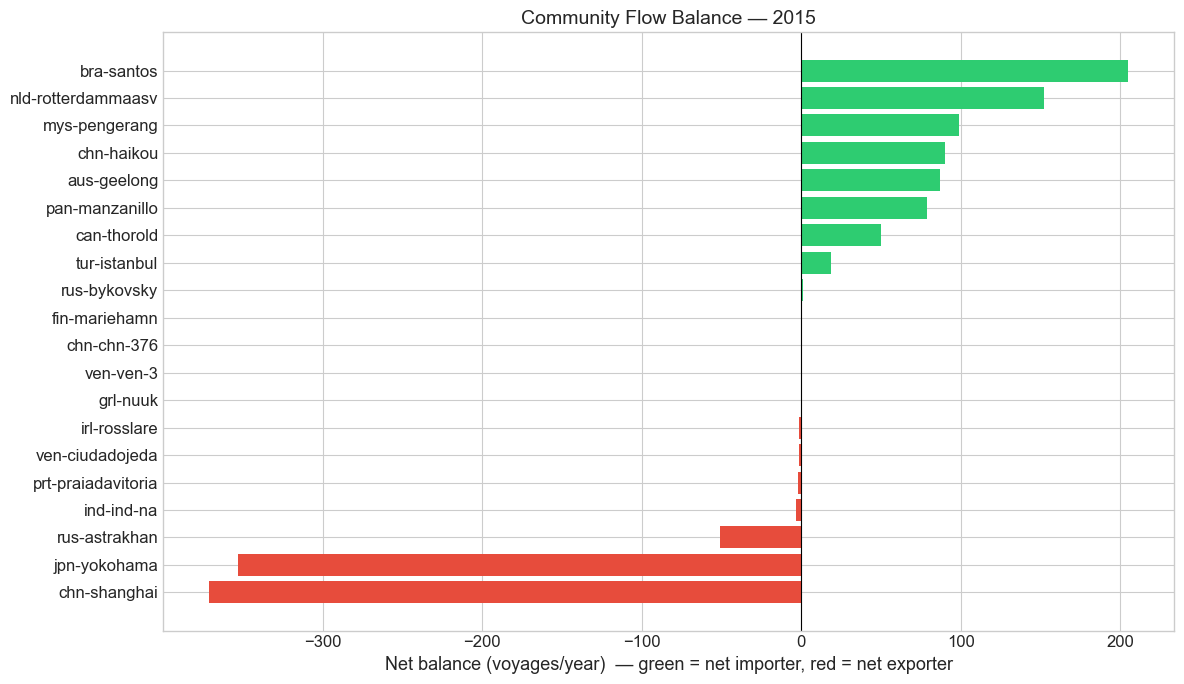

Saved → ../Figures/04_community_flow_2015.csv

Community flow balance — 2025
 Comm ID     Top port (hub)  Size  Inflow  Outflow  Balance  Balance %         Role
       3   mys-telokramunia   760   47716    46972      744        0.8 net importer
       8         bra-santos   255   12517    12318      199        0.8 net importer
      28     pan-manzanillo   753   12974    12834      140        0.5 net importer
      23       tur-istanbul  1146   20621    20516      105        0.3 net importer
      11        aus-geelong   228    6320     6227       93        0.7 net importer
      15        can-thorold   146    1765     1693       72        2.1 net importer
       4      chn-guangzhou   244   58175    58152       23        0.0 net importer
       0      rus-astrakhan   244     939      926       13        0.7 net importer
       1 prt-praiadavitoria     9      33       31        2        3.1 net importer
      21         chl-chl-55    39     144      142        2        0.7 net importer

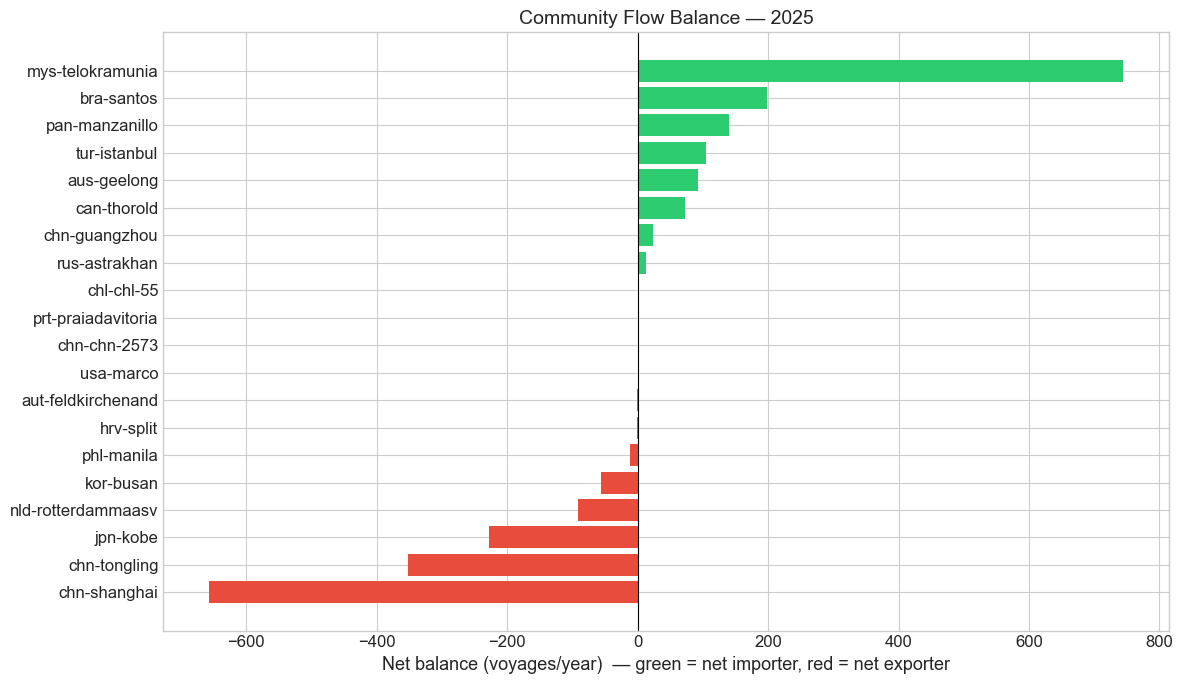

Saved → ../Figures/04_community_flow_2025.csv


In [ ]:
# Defining a function that computes the net directed flow (inflow minus outflow) for each community using the directed weighted graph, then visualises the top imbalances
def community_flow_balance(Gd_w, comms, node_to_comm, Gu, label, min_size=3):

    """Compute directed inflow / outflow / balance per community."""

    n_comms = len(comms)
    inflow  = np.zeros(n_comms)   # Total voyages arriving at each community from outside
    outflow = np.zeros(n_comms)   # Total voyages departing each community to outside
 
    for u, v, d in Gd_w.edges(data=True):    # Iterating over all directed edges
        w  = d.get('weight', 1)
        cu = node_to_comm.get(u)              # Source community
        cv = node_to_comm.get(v)              # Destination community
        if cu is None or cv is None or cu == cv:
            continue    # Skipping the internal (same-community) edges and unmapped nodes
        outflow[cu] += w   # Edge leaves community cu
        inflow[cv]  += w   # Edge enters community cv
 
    rows = []
    for i, comm in enumerate(comms): # Iterating over all communities

        if len(comm) < min_size:   # Skip tiny communities
            continue

        inf, outf = inflow[i], outflow[i]
        balance   = inf - outf     # If Positive = net importer, otherwise if negative = net exporter
        total_ext = inf + outf     # Calculating the total external voyage volume for this community

        # Classifying each community by the sign of its balance
        role      = 'net importer' if balance > 0 else ('net exporter' if balance < 0 else 'balanced')
        rows.append({
            'Comm ID': i,
            'Top port (hub)': top_port_label(comm, Gu),
            'Size': len(comm),
            'Inflow': int(inf),
            'Outflow': int(outf),
            'Balance': int(balance),
            'Balance %': round(balance / total_ext * 100, 1) if total_ext > 0 else 0,  # Normalised asymmetry
            'Role': role,
        })
 
    # Sorting by balance in descending order, biggest net importers at top, exporters at bottom
    df = pd.DataFrame(rows).sort_values('Balance', ascending=False)
    print(f'\nCommunity flow balance — {label}')
    print(df.to_string(index=False)) # Showing the df
 
    # ── Horizontal bar chart: top 20 communities by absolute balance ──
    df_plot = df.reindex(df['Balance'].abs().nlargest(20).index)  # Selecting 20 most imbalanced
    df_plot = df_plot.sort_values('Balance')                       # Sorting in ascending order for readable chart
    colors_bar = ['#2ecc71' if b >= 0 else '#e74c3c' for b in df_plot['Balance']]  # Green = importer, red = exporter
 
    # Plotting the Community Flow Balance
    fig, ax = plt.subplots(figsize=(12, 7))
    ax.barh(df_plot['Top port (hub)'], df_plot['Balance'],
            color=colors_bar, edgecolor='none')
    ax.axvline(0, color='k', lw=0.8)  # Zero reference line separates importers from exporters
    ax.set_xlabel('Net balance (voyages/year)  — green = net importer, red = net exporter')
    ax.set_title(f'Community Flow Balance — {label}')
    plt.tight_layout()
    plt.savefig(FIG_DIR + f'04_community_flow_{label}.png', dpi=150, bbox_inches='tight')
    plt.show()
 
    df.to_csv(FIG_DIR + f'04_community_flow_{label}.csv', index=False)
    print(f'Saved → ../Figures/04_community_flow_{label}.csv')
    return df
 
# Running the community flow balance analysis for both years
flow_2015 = community_flow_balance(Gd_2015, comms_2015, cm_2015['node_to_comm'], Gu_2015, '2015')
flow_2025 = community_flow_balance(Gd_2025, comms_2025, cm_2025['node_to_comm'], Gu_2025, '2025')
 

---
## 11. Community Quality Metrics — Conductance & Coverage

Standard graph-partitioning quality metrics assess how "good" the communities are:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **Conductance** φ(C) | cut(C) / min(vol(C), vol(V\C)) | lower = better boundary, range [0,1] |
| **Coverage** | intra-edges / all edges | higher = more traffic within communities |
| **Performance** | (intra-edges + non-edges between comms) / total pairs | higher = better |

Kaluza et al. report Q ≈ 0.60–0.72; we check the complementary metrics that Q does not capture.


=== Community Quality Metrics — 2015 ===
  Coverage             : 0.7020  (fraction of edges inside communities)
  Performance          : 0.8595  (correct intra + non-edges / total pairs)
  Mean conductance φ   : 0.0959  (lower = better-separated communities)
  Min  conductance     : 0.0000
  Max  conductance     : 0.3140


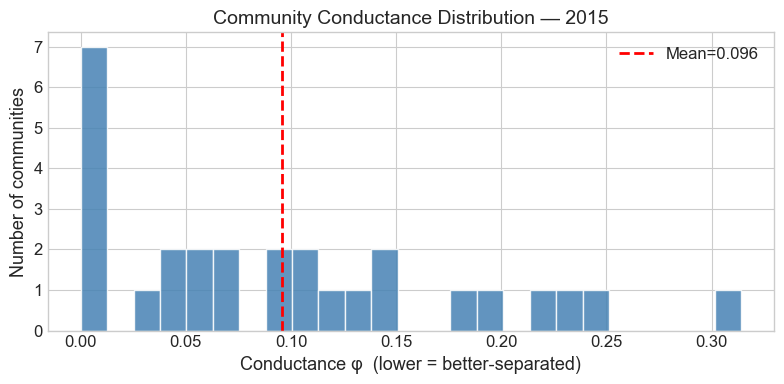


=== Community Quality Metrics — 2025 ===
  Coverage             : 0.6760  (fraction of edges inside communities)
  Performance          : 0.8937  (correct intra + non-edges / total pairs)
  Mean conductance φ   : 0.0942  (lower = better-separated communities)
  Min  conductance     : 0.0000
  Max  conductance     : 0.3675


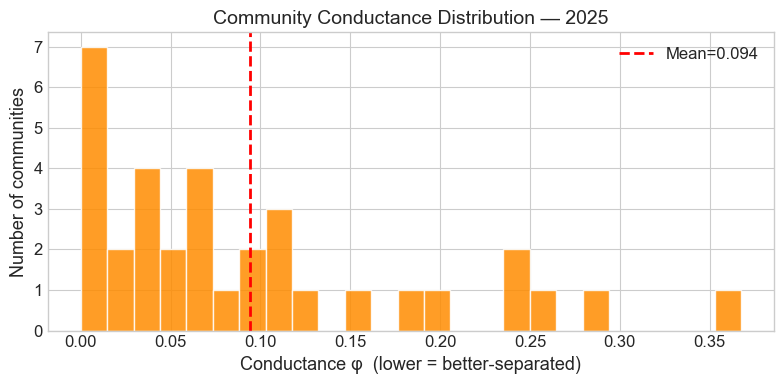

In [ ]:
# Defining a function to compute the conductance, coverage and performance for the partition
def community_quality(Gu, comms, label):
    """Compute conductance, coverage and performance for the partition.

    All three metrics are implemented manually to avoid NetworkX version
    differences (coverage/performance moved across releases).

    coverage    = intra-community edges / total edges
    performance = (intra-edges + inter-non-edges) / total node pairs
    conductance = cut(C) / min(vol(C), vol(V\C))  — per community, weighted
    """
    # Assigning community ids to each node belonging to each community
    node_to_comm = {}
    for i, c in enumerate(comms):
        for n in c:
            node_to_comm[n] = i

    # Calculating the number of edges and nodes in the given undirected graph
    N = Gu.number_of_nodes()
    M = Gu.number_of_edges()

    # ── Coverage ──────────────────────────────────────────────────────
    # Calculating the fraction of edges whose both endpoints belong to the same community
    intra_edges = sum(
        1 for u, v in Gu.edges()
        if node_to_comm.get(u) == node_to_comm.get(v)
    )
    cov = intra_edges / M if M > 0 else 0.0

    # ── Performance ───────────────────────────────────────────────────
    # (correctly placed edges + correctly placed non-edges) / total pairs
    # A pair (u,v) is "correct" if:
    #   same community  AND edge exists, OR
    #   diff community  AND no edge
    edge_set = set(Gu.edges()) | {(v, u) for u, v in Gu.edges()}
    correct = 0
    total_pairs = N * (N - 1) // 2
    for i, ci in enumerate(comms):
        ci = list(ci)
        for a_idx in range(len(ci)):
            for b_idx in range(a_idx + 1, len(ci)):
                u, v = ci[a_idx], ci[b_idx]
                if (u, v) in edge_set or (v, u) in edge_set:
                    correct += 1   # same community, edge present

    # Inter-community non-edges
    # total pairs - intra_pairs - inter_edges
    intra_pairs = sum(len(c) * (len(c) - 1) // 2 for c in comms)
    inter_edges = M - intra_edges
    inter_pairs = total_pairs - intra_pairs
    inter_non_edges = inter_pairs - inter_edges
    correct += inter_non_edges
    perf = correct / total_pairs if total_pairs > 0 else 0.0

    # Calculating the Conductance (weighted)
    vol = np.zeros(len(comms))
    cut = np.zeros(len(comms))
    for u, v, d in Gu.edges(data=True):
        w  = d.get('weight', 1)
        cu = node_to_comm.get(u)
        cv = node_to_comm.get(v)
        if cu is None or cv is None:
            continue
        vol[cu] += w
        vol[cv] += w
        if cu != cv:
            cut[cu] += w
            cut[cv] += w

    total_vol = vol.sum()
    conductances = []
    for i in range(len(comms)):
        denom = min(vol[i], total_vol - vol[i])
        if denom > 0:
            conductances.append(cut[i] / denom)

    conductances = np.array(conductances)
    mean_cond    = conductances.mean() if len(conductances) > 0 else np.nan

    # Printing the above computed metrics for communities given
    print(f'\n=== Community Quality Metrics — {label} ===')
    print(f'  Coverage             : {cov:.4f}  (fraction of edges inside communities)')
    print(f'  Performance          : {perf:.4f}  (correct intra + non-edges / total pairs)')
    print(f'  Mean conductance φ   : {mean_cond:.4f}  (lower = better-separated communities)')
    print(f'  Min  conductance     : {conductances.min():.4f}')
    print(f'  Max  conductance     : {conductances.max():.4f}')

    # Plotting the Conductance distribution
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(conductances, bins=25,
            color='steelblue' if label == '2015' else 'darkorange',
            edgecolor='white', alpha=0.85)
    ax.axvline(mean_cond, color='red', lw=2, ls='--', label=f'Mean={mean_cond:.3f}')
    ax.set_xlabel('Conductance φ  (lower = better-separated)')
    ax.set_ylabel('Number of communities')
    ax.set_title(f'Community Conductance Distribution — {label}')
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR + f'04_conductance_{label}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return {'coverage': cov, 'performance': perf,
            'mean_conductance': mean_cond, 'conductances': conductances}

# Performing the community quality analysis for each year's community data
qual_2015 = community_quality(Gu_2015, comms_2015, '2015')
qual_2025 = community_quality(Gu_2025, comms_2025, '2025')

---
## 13. Full Community Summary & Consolidated Output

Consolidates all community metrics into one comprehensive comparison table and prints key findings.

In [ ]:
# Constructing the consolidated comparison table
rows_full = [
    ('DETECTION', '', '', ''),
    ('Algorithm',                   method_2015,                                   method_2025,                                   'Leicht-Newman modularity'),
    ('Communities c',               str(len(comms_2015)),                           str(len(comms_2025)),                           '12 / 7 / 6 (per type)'),
    ('Modularity Q',                f'{Q_2015:.4f}',                               f'{Q_2025:.4f}',                               '0.605 / 0.592 / 0.716'),
    ('COMMUNITY STRUCTURE', '', '', ''),
    ('Largest community (nodes)',   str(cm_2015["sizes"].max()),                    str(cm_2025["sizes"].max()),                    '—'),
    ('Smallest community (nodes)',  str(cm_2015["sizes"].min()),                    str(cm_2025["sizes"].min()),                    '—'),
    ('Mean community size',         f'{cm_2015["sizes"].mean():.1f}',              f'{cm_2025["sizes"].mean():.1f}',              '—'),
    ('Intra-edge ratio',            f'{cm_2015["intra_ratio"]*100:.1f}%',          f'{cm_2025["intra_ratio"]*100:.1f}%',          '—'),
    ('Intra-traffic ratio',         f'{cm_2015["intra_traffic_ratio"]*100:.1f}%',  f'{cm_2025["intra_traffic_ratio"]*100:.1f}%',  '—'),
    ('Mean internal density',       f'{np.mean(cm_2015["densities"]):.4f}',        f'{np.mean(cm_2025["densities"]):.4f}',        '—'),
    ('QUALITY METRICS', '', '', ''),
    ('Coverage',                    f'{qual_2015["coverage"]:.4f}',                f'{qual_2025["coverage"]:.4f}',                '—'),
    ('Performance',                 f'{qual_2015["performance"]:.4f}',             f'{qual_2025["performance"]:.4f}',             '—'),
    ('Mean conductance φ',          f'{qual_2015["mean_conductance"]:.4f}',        f'{qual_2025["mean_conductance"]:.4f}',        '—'),
    ('EVOLUTION (2015→2025)', '', '', ''),
    ('Stable communities (J≥0.25)', str(n_stable),                                  '—',                                          '—'),
    ('Dissolved/split communities', str(n_dissolved),                               '—',                                          '—'),
]

# Converting the above constructed summary table into a dataframe
df_full = pd.DataFrame(rows_full, columns=['Metric', '2015', '2025', 'Paper 2007'])

# Printing the above constructed summary table
print()
print('=' * 95)
print('  GCSN COMMUNITY ANALYSIS — FULL SUMMARY TABLE')
print('  Reference: Kaluza et al. (2010), J. R. Soc. Interface, doi:10.1098/rsif.2009.0495')
print('=' * 95)
print(df_full.to_string(index=False))
print('=' * 95)
df_full.to_csv(FIG_DIR + '04_community_summary_full.csv', index=False)
print('\nFull summary saved → ../Figures/04_community_summary_full.csv')

# Printing the key findings we found after doing the community analysis based on all the above code cells
print()
print('=' * 72)
print('  KEY FINDINGS — COMMUNITY ANALYSIS')
print('=' * 72)
print(f'  1. Community count: {len(comms_2015)} (2015) → {len(comms_2025)} (2025)')
q_chg = Q_2025 - Q_2015
print(f'  2. Modularity Q: {Q_2015:.4f} → {Q_2025:.4f}  ({q_chg:+.4f})  '      f'({"more" if q_chg > 0 else "less"} modular in 2025)')
print(f'  3. Intra-community traffic: {cm_2015["intra_traffic_ratio"]*100:.1f}% → '      f'{cm_2025["intra_traffic_ratio"]*100:.1f}%')
print(f'  4. Coverage: {qual_2015["coverage"]:.4f} → {qual_2025["coverage"]:.4f}')
print(f'  5. Mean conductance: {qual_2015["mean_conductance"]:.4f} → {qual_2025["mean_conductance"]:.4f}  '      f'({"improved" if qual_2025["mean_conductance"] < qual_2015["mean_conductance"] else "worsened"} community boundaries)')
print(f'  6. Community persistence: {n_stable} of {len(comms_2015)} 2015 communities '      f'have a recognisable 2025 counterpart  (Jaccard >= 0.25)')
net_imp_15 = (flow_2015['Balance'] > 0).sum()
net_exp_15 = (flow_2015['Balance'] < 0).sum()
print(f'  7. Flow balance (2015): {net_imp_15} net-importing, {net_exp_15} net-exporting communities')
net_imp_25 = (flow_2025['Balance'] > 0).sum()
net_exp_25 = (flow_2025['Balance'] < 0).sum()
print(f'     Flow balance (2025): {net_imp_25} net-importing, {net_exp_25} net-exporting communities')
print('=' * 72)



  GCSN COMMUNITY ANALYSIS — FULL SUMMARY TABLE
  Reference: Kaluza et al. (2010), J. R. Soc. Interface, doi:10.1098/rsif.2009.0495
                     Metric    2015    2025               Paper 2007
                  DETECTION                                         
                  Algorithm Louvain Louvain Leicht-Newman modularity
              Communities c      28      34    12 / 7 / 6 (per type)
               Modularity Q  0.6987  0.7196    0.605 / 0.592 / 0.716
        COMMUNITY STRUCTURE                                         
  Largest community (nodes)    1990    1735                        —
 Smallest community (nodes)       2       2                        —
        Mean community size   253.5   227.0                        —
           Intra-edge ratio   70.2%   67.6%                        —
        Intra-traffic ratio   84.2%   83.4%                        —
      Mean internal density  0.4647  0.3605                        —
            QUALITY METRICS             